In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

print("Environment ready for web scraping ✅")


Environment ready for web scraping ✅


In [2]:
url = "https://www.truerp.in/"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
print("Status Code:", response.status_code)

soup = BeautifulSoup(response.text, "html.parser")
headings = []

for tag in ["h1", "h2", "h3"]:
    for h in soup.find_all(tag):
        text = h.get_text(strip=True)
        if text:
            headings.append({"Tag": tag.upper(), "Text": text})

pd.DataFrame(headings)


Status Code: 406


,Tag,Text
0,H1,Not Acceptable!


Observation:
The website returned HTTP 406 (Not Acceptable), indicating bot protection.
Standard HTTP requests were blocked, so browser-based scraping is required.


In [3]:
%pip install playwright


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
!playwright install chromium


'playwright' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
!python -m playwright install chromium


|                                                                                |   0% of 169.8 MiB
|â– â– â– â– â– â– â– â–                                                                         |  10% of 169.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                                 |  20% of 169.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                         |  30% of 169.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                                 |  40% of 169.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–                                         |  50% of 169.8 MiB
|â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â– â–          

(node:11500) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
(node:8744) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
(node:9764) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to errors that have security implications. Use the WHATWG URL API instead. CVEs are not issued for `url.parse()` vulnerabilities.
(Use `node --trace-deprecation ...` to show where the warning was created)
(node:11636) [DEP0169] DeprecationWarning: `url.parse()` behavior is not standardized and prone to 

In [6]:
%%writefile scrape_truerp.py
import asyncio
import pandas as pd
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright

async def main():
    url = "https://www.truerp.in/"

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()


        await page.goto(url, wait_until="domcontentloaded", timeout=120000)
        await page.wait_for_timeout(3000)  

        html = await page.content()
        await browser.close()

    soup = BeautifulSoup(html, "html.parser")
    data = []

    for tag in ["h1", "h2", "h3"]:
        for h in soup.find_all(tag):
            text = h.get_text(" ", strip=True)
            if text:
                data.append({"Tag": tag.upper(), "Text": text})

    df = pd.DataFrame(data).drop_duplicates()
    df.to_csv("truerp_headings.csv", index=False)
    print("Saved: truerp_headings.csv")
    print(df.head(10))

if __name__ == "__main__":
    asyncio.run(main())


Overwriting scrape_truerp.py


In [7]:
!python scrape_truerp.py


Saved: truerp_headings.csv
  Tag                                               Text
0  H1  Smart ERP for the Manufacturing & Mechanical I...
1  H2  Powering Efficiency. Driving Growth. Simplifyi...
2  H2                                           Features
3  H2                                       Testimonials
4  H2                                           Services
5  H2                                            Pricing
6  H2                 Have a question? Check out the FAQ
7  H2                                            Contact
8  H3                                          15+ Years
9  H3                                     Tanaji Tengale


In [8]:
import pandas as pd
df = pd.read_csv("truerp_headings.csv")
df


,Tag,Text
0,H1,Smart ERP for the Manufacturing & Mechanical I...
1,H2,Powering Efficiency. Driving Growth. Simplifyi...
2,H2,Features
3,H2,Testimonials
4,H2,Services
5,H2,Pricing
6,H2,Have a question? Check out the FAQ
7,H2,Contact
8,H3,15+ Years
9,H3,Tanaji Tengale


In [9]:
df["Text"] = df["Text"].astype(str).str.strip()
df = df[df["Text"].str.len() > 2]          
df = df.drop_duplicates()
df.head()


,Tag,Text
0,H1,Smart ERP for the Manufacturing & Mechanical I...
1,H2,Powering Efficiency. Driving Growth. Simplifyi...
2,H2,Features
3,H2,Testimonials
4,H2,Services


In [10]:
tag_counts = df["Tag"].value_counts()
tag_counts


Tag
H3    21
H2     7
H1     1
Name: count, dtype: int64

In [11]:
import re
from collections import Counter

text = " ".join(df["Text"].tolist()).lower()
words = re.findall(r"[a-z]+", text)

stopwords = {"the","and","for","to","of","in","a","is","are","with","your","you","our","have","check","out"}
keywords = [w for w in words if w not in stopwords and len(w) > 2]

Counter(keywords).most_common(15)


[('truerp', 4),
 ('manufacturing', 3),
 ('operations', 2),
 ('contact', 2),
 ('management', 2),
 ('scale', 2),
 ('can', 2),
 ('end', 2),
 ('business', 2),
 ('based', 2),
 ('get', 2),
 ('smart', 1),
 ('erp', 1),
 ('mechanical', 1),
 ('industry', 1)]

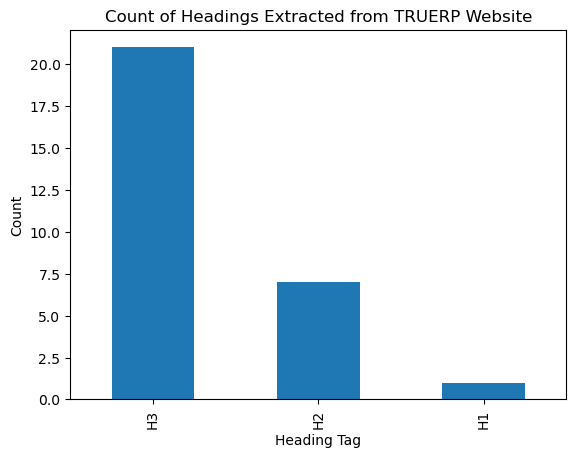

In [12]:
import matplotlib.pyplot as plt

tag_counts.plot(kind="bar")
plt.title("Count of Headings Extracted from TRUERP Website")
plt.xlabel("Heading Tag")
plt.ylabel("Count")
plt.show()
